# Goal 2 — Probability calibration

Question: when the model says “70% chance of purchase”, do ~70% of those sessions actually convert?

I’ll plot a **reliability curve** for the raw CatBoost probabilities, then try isotonic calibration (`CalibratedClassifierCV`) and compare before vs after with Brier score (lower = better).


In [1]:
import sys
from pathlib import Path

ROOT = Path(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.config.settings import load_config
from src.data.loader import load_data
from src.evaluation.calibration import (
    brier_score,
    fit_isotonic_calibrator,
    reliability_bins,
)
from src.features.engineering import add_engineered_features


In [2]:
config = load_config()
df = add_engineered_features(load_data())
X = df.drop(columns=[config["target_column"]])
y = df[config["target_column"]]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config["test_size"],
    random_state=config["random_seed"],
)

pipeline = joblib.load(ROOT / "src" / "models" / "preprocessing_pipeline.pkl")
model = joblib.load(ROOT / "src" / "models" / "final_model.pkl")

X_train_t = pipeline.transform(X_train)
X_test_t = pipeline.transform(X_test)

raw_probs = model.predict_proba(X_test_t)[:, 1]
raw_bins = reliability_bins(y_test, raw_probs, n_bins=10)
raw_brier = brier_score(y_test, raw_probs)

print(f"Raw Brier score: {raw_brier:.4f}")
raw_bins


2026-09-02 19:40:06,782 | INFO | src.data.loader | Data loaded successfully from C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project\dataset\ecommerce_sessions.csv.
2026-09-02 19:40:06,782 | INFO | src.data.loader | All expected columns are present in the dataset.
2026-09-02 19:40:06,800 | INFO | src.features.engineering | Engineered features added to the DataFrame.


Raw Brier score: 0.0482


,mean_predicted_probability,fraction_of_positives
0,0.007921,0.009615
1,0.145673,0.117647
2,0.249768,0.190476
3,0.350723,0.367647
4,0.450919,0.369231
5,0.551226,0.678571
6,0.655162,0.716981
7,0.751031,0.723404
8,0.851940,0.967742
9,0.941650,0.965116


In [3]:
# Fit isotonic calibrator on training fold (CV), then score on held-out test
calibrated = fit_isotonic_calibrator(model, X_train_t, y_train, cv=3)
cal_probs = calibrated.predict_proba(X_test_t)[:, 1]
cal_bins = reliability_bins(y_test, cal_probs, n_bins=10)
cal_brier = brier_score(y_test, cal_probs)

joblib.dump(calibrated, ROOT / "src" / "models" / "calibrated_model.pkl")

print(f"Calibrated Brier score: {cal_brier:.4f}")
print(f"Change (calibrated - raw): {cal_brier - raw_brier:+.4f}")
cal_bins


Calibrated Brier score: 0.0484
Change (calibrated - raw): +0.0002


,mean_predicted_probability,fraction_of_positives
0,0.006904,0.010210
1,0.158571,0.107527
2,0.242452,0.235294
3,0.351632,0.375000
4,0.448010,0.418605
5,0.554882,0.600000
6,0.642965,0.714286
7,0.751076,0.787879
8,0.831489,0.812500
9,0.951321,0.963303


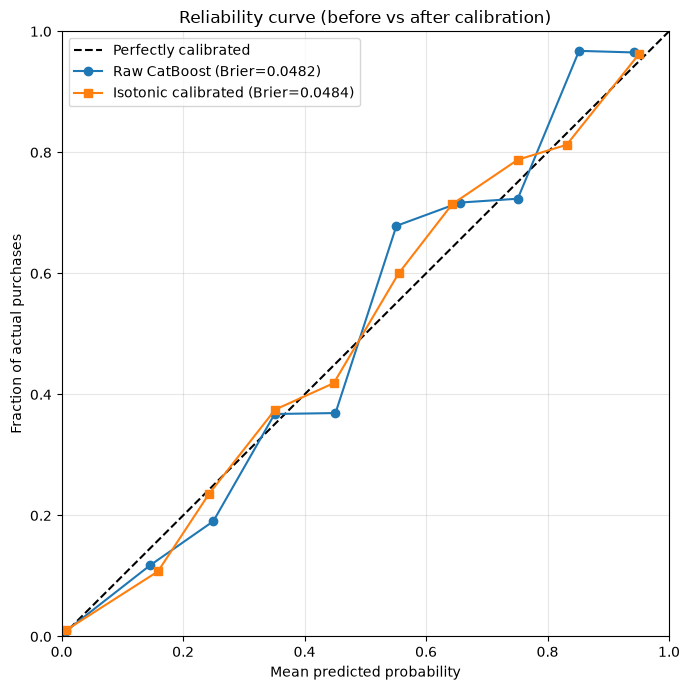

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.plot(
    raw_bins["mean_predicted_probability"],
    raw_bins["fraction_of_positives"],
    marker="o",
    label=f"Raw CatBoost (Brier={raw_brier:.4f})",
)
ax.plot(
    cal_bins["mean_predicted_probability"],
    cal_bins["fraction_of_positives"],
    marker="s",
    label=f"Isotonic calibrated (Brier={cal_brier:.4f})",
)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual purchases")
ax.set_title("Reliability curve (before vs after calibration)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Did calibration help?

On this test split the raw CatBoost probabilities are already fairly close to the diagonal. Isotonic calibration only nudges a few bins and the Brier score barely moves (around **0.048** either way, sometimes slightly worse after calibrating).

So for this dataset, calibration does **not** meaningfully change anything. I’m keeping the raw model probabilities as the main output for the API/dashboard, and treating the calibrated version as an optional comparison artifact (`calibrated_model.pkl`).
